In [1]:
import _referAsMain
import sys; print(sys.version_info)
from datasets import load_dataset
import torch, random, time, math
from IPython.display import SVG, display

added '/autofs/unitytravail/travail/jmayol/master 2/pfe/PFE_LLM_art_generation' to import paths
sys.version_info(major=3, minor=10, micro=19, releaselevel='final', serial=0)


/autofs/unitytravail/travail/jmayol/master 2/pfe/PFE_LLM_art_generation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

Torch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
Device count: 1


In [3]:
from paths_cfg import CURRENT_DIRECTORY
from dataset import svg_dataset
dataset = svg_dataset.SVGDataset(CURRENT_DIRECTORY.joinpath("dataset/samples"))

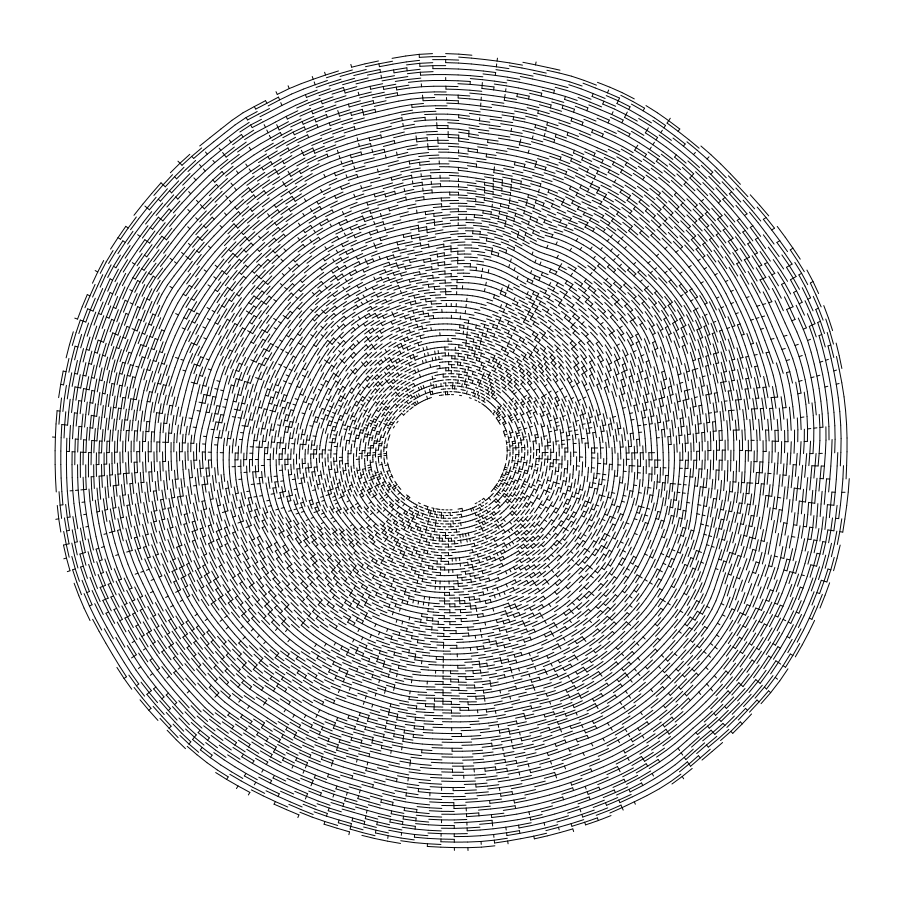

In [4]:
display(SVG(data=dataset.samples[23].txt))

In [5]:
import LLM.nanochat.gpt as nanoChatModel
import LLM.nanochat.tokenizer as tokenizerLib
from LLM.nanochat.common import compute_init, autodetect_device_type

In [6]:
device_type = "cuda"
device_type = (autodetect_device_type() if device_type == "" else device_type)
ddp, ddp_rank, ddp_local_rank, ddp_world_size, device = compute_init(device_type)

2026-02-24 14:54:22,069 - LLM.nanochat.common - INFO - Distributed world size: 1


In [7]:
tokenizerPreTrained = tokenizerLib.HuggingFaceTokenizer.from_pretrained("gpt2")
#tokenizerPreTrained = tokenizerLib.HuggingFaceTokenizer.from_pretrained("xlnet/xlnet-base-cased")

2026-02-24 14:54:22,250 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/gpt2/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-02-24 14:54:22,362 - httpx - INFO - HTTP Request: GET https://huggingface.co/gpt2/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-02-24 14:54:22,363 - huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


In [8]:
from tokenizer_pfe.tokenizer_project import SPECIAL_TOKENS

In [10]:
tokenizerTrainedSmallest = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    (svg.txt for svg in dataset.samples[: 5]), vocab_size=2048, special_tokens= SPECIAL_TOKENS)

In [12]:
tokenizerTrainedSmall = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    (svg.txt for svg in dataset.samples[: 15]), vocab_size=2048, special_tokens= SPECIAL_TOKENS)

In [13]:
tokenizerTrainedMedium = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    (svg.txt for svg in dataset.samples[: 20]), vocab_size=2048, special_tokens= SPECIAL_TOKENS)

In [14]:
tokenizerTrained = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    (svg.txt for svg in dataset.samples[: 33]), vocab_size=2048, special_tokens= SPECIAL_TOKENS)

In [15]:
tokenizerTrainedLarge = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    (svg.txt for svg in dataset.samples[: 50]), vocab_size=2048*2, special_tokens= SPECIAL_TOKENS)

In [ ]:
tokenizerTrainedLargest = tokenizerLib.HuggingFaceTokenizer.train_from_iterator(
    (svg.txt for svg in dataset.samples[: 100]), vocab_size=2048*2, special_tokens= SPECIAL_TOKENS)

In [43]:
tokenizer = tokenizerTrainedLargest
vocab_size = tokenizer.get_vocab_size()
print(vocab_size)
display(sorted([(id, tk) for tk, id in tokenizer.tokenizer.get_vocab().items()], reverse=False))
OutStart_Token = "<|output_start|>"
OutEnd_Token = "<|output_end|>"
OutEnd_ids = tokenizer.encode(OutEnd_Token); assert len(OutEnd_ids) == 1
OutEnd_id = OutEnd_ids[0]; del OutEnd_ids

585


[(0, '<|output_start|>'),
 (1, '<|output_end|>'),
 (2, '!'),
 (3, '"'),
 (4, '#'),
 (5, '$'),
 (6, '%'),
 (7, '&'),
 (8, "'"),
 (9, '('),
 (10, ')'),
 (11, '*'),
 (12, '+'),
 (13, ','),
 (14, '-'),
 (15, '.'),
 (16, '/'),
 (17, '0'),
 (18, '1'),
 (19, '2'),
 (20, '3'),
 (21, '4'),
 (22, '5'),
 (23, '6'),
 (24, '7'),
 (25, '8'),
 (26, '9'),
 (27, ':'),
 (28, ';'),
 (29, '<'),
 (30, '='),
 (31, '>'),
 (32, '?'),
 (33, '@'),
 (34, 'A'),
 (35, 'B'),
 (36, 'C'),
 (37, 'D'),
 (38, 'E'),
 (39, 'F'),
 (40, 'G'),
 (41, 'H'),
 (42, 'I'),
 (43, 'J'),
 (44, 'K'),
 (45, 'L'),
 (46, 'M'),
 (47, 'N'),
 (48, 'O'),
 (49, 'P'),
 (50, 'Q'),
 (51, 'R'),
 (52, 'S'),
 (53, 'T'),
 (54, 'U'),
 (55, 'V'),
 (56, 'W'),
 (57, 'X'),
 (58, 'Y'),
 (59, 'Z'),
 (60, '['),
 (61, '\\'),
 (62, ']'),
 (63, '^'),
 (64, '_'),
 (65, '`'),
 (66, 'a'),
 (67, 'b'),
 (68, 'c'),
 (69, 'd'),
 (70, 'e'),
 (71, 'f'),
 (72, 'g'),
 (73, 'h'),
 (74, 'i'),
 (75, 'j'),
 (76, 'k'),
 (77, 'l'),
 (78, 'm'),
 (79, 'n'),
 (80, 'o'),
 (81, 'p'

In [21]:
print(type(tokenizer.tokenizer))

<class 'tokenizers.Tokenizer'>


In [60]:
aspect_ratio = 10.5
head_dim = 128
max_seq_len = 2048*8
window_pattern = "SSSL"

def build_model_meta(depth):
    """Build a model on meta device for a given depth (shapes/dtypes only, no data)."""
    # Model dim is nudged up to nearest multiple of head_dim for clean division
    # (FA3 requires head_dim divisible by 8, and this guarantees head_dim == args.head_dim exactly)
    base_dim = depth * aspect_ratio
    model_dim = int(((base_dim + head_dim - 1) // head_dim) * head_dim)
    num_heads = int(model_dim // head_dim)
    config = nanoChatModel.GPTConfig(
        sequence_len=max_seq_len, vocab_size=vocab_size,
        n_layer=depth, n_head=num_heads, n_kv_head=num_heads, n_embd=model_dim,
        window_pattern=window_pattern,
    )
    print(config)
    with torch.device("meta"):
        model_meta = nanoChatModel.GPT(config)
    return model_meta

model = build_model_meta(6)
model.to_empty(device=device) # 2) All tensors get storage on target device but with uninitialized (garbage) data
model.init_weights() # 3) All tensors get initialized
optimizer = model.setup_optimizer()

params = model.num_scaling_params(); print(params.items())
params_Embed = (params['wte'] + params['value_embeds'])
print(f"{params['total']:_d} params "
      f"(with embeding: {params_Embed:_d} | "
      f"last layer: {params['lm_head']:_d} | "
      f"transformer: {params['transformer_matrices']:_d})"
    )
model = model.bfloat16()

model = torch.compile(model, dynamic=False) # the inputs to model will never change shape so dynamic=False is safe
#model.eval();


GPTConfig(sequence_len=16384, vocab_size=585, n_layer=6, n_head=1, n_kv_head=1, n_embd=128, window_pattern='SSSL')
Padding vocab_size from 585 to 640 for efficiency
Scaling the LR for the AdamW parameters ∝1/√(128/768) = 2.449490
dict_items([('wte', 81920), ('value_embeds', 245760), ('lm_head', 81920), ('transformer_matrices', 1179744), ('scalars', 12), ('total', 1589356)])
1_589_356 params (with embeding: 327_680 | last layer: 81_920 | transformer: 1_179_744)


In [61]:
svg = dataset.samples[-57].txt
encoded = tokenizer.tokenizer.encode(svg)
print(f"{len(svg):_d}, {len(encoded.ids):_d}")
print(encoded.ids)
print(" ".join(encoded.tokens))

103_449, 48_050
[519, 487, 518, 258, 491, 465, 492, 460, 20, 496, 16, 328, 365, 514, 3, 487, 258, 491, 465, 492, 460, 20, 496, 16, 382, 386, 513, 3, 269, 258, 273, 503, 27, 18, 28, 490, 441, 425, 28, 490, 581, 425, 28, 572, 441, 425, 28, 406, 497, 28, 406, 428, 583, 28, 406, 582, 27, 384, 28, 573, 441, 425, 28, 406, 503, 27, 18, 28, 484, 497, 28, 406, 577, 275, 28, 440, 565, 502, 28, 406, 511, 27, 18, 28, 440, 579, 515, 570, 505, 440, 566, 502, 28, 406, 576, 517, 28, 440, 580, 27, 350, 539, 28, 406, 578, 27, 17, 28, 574, 441, 425, 268, 485, 258, 385, 17, 3, 486, 258, 385, 17, 504, 528, 547, 258, 560, 276, 72, 266, 72, 269, 258, 427, 428, 444, 28, 484, 498, 28, 406, 498, 456, 556, 260, 258, 17, 3, 485, 258, 385, 17, 3, 486, 258, 385, 17, 3, 261, 258, 17, 3, 269, 258, 427, 275, 575, 72, 266, 72, 269, 258, 427, 428, 444, 456, 278, 261, 19, 258, 289, 15, 316, 320, 3, 269, 258, 273, 275, 268, 260, 18, 258, 291, 15, 287, 295, 3, 260, 19, 258, 355, 21, 15, 333, 377, 3, 261, 18, 258, 285, 15, 

In [62]:
def show(gen):
    results = []
    memStart = torch.cuda.memory.memory_reserved()
    for nb, token in enumerate(gen):
        decoded = tokenizer.decode([token])
        results.append(decoded)
        #print(decoded, end="", flush=True)
        print(nb, end="\r", flush=True)
        if token == OutEnd_id:
            break
        memCurr = torch.cuda.memory.memory_reserved()
        if (memCurr-memStart) > 2 * 1e9: # using ..Go
            torch.cuda.memory.empty_cache()
            
    torch.cuda.memory.empty_cache()
    print()
    return results

In [67]:
torch.cuda.memory.empty_cache()
inputs_text = "" + OutStart_Token
#inputs_text =  "SVG of a brick." + OutStart_Token
tokens = tokenizer.encode(inputs_text)
print(f"nb tokens in the input: {len(tokens):_d}")

print(inputs_text)
nbToGen = 8000
tStart = time.perf_counter()
with torch.device(device):
    generated = show(model.generate(
        tokens=tokens, max_tokens=nbToGen, 
        temperature=1, top_k=None, seed=random.randint(0, 10_000)))
tTaken = (time.perf_counter() - tStart)
print(f'took: {tTaken:.2f} sec, ({len(generated)/tTaken:.2f} token/sec)')
print(inputs_text + "".join(generated))

nb tokens in the input: 1
<|output_start|>
7999
took: 45.20 sec, (177.01 token/sec)
<|output_start|><svg xmlns:xlink="http://www.w3.org/1999/xlink" xmlns="http://www.w3.org/2000/svg" style="fill-opacity:1; color-rendering:auto; color-interpolation:auto; text-rendering:auto; stroke:black; stroke-linecap:square; stroke-miterlimit:10; shape-rendering:auto; stroke-opacity:1; fill:black; stroke-dasharray:none; font-weight:normal; stroke-width:1; font-family:'Dialog'; font-style:normal; stroke-linejoin:miter; font-size:12px; stroke-dashoffset:0; image-rendering:auto;" width="900" height="900"><defs id="genericDefs"/><g><g style="stroke-linecap:round; fill:white; stroke:white;"><rect x="0" width="900" height="900" y="0" style="stroke:none;"/></g><g style="stroke-linecap:round;"><line y2="433.9146" style="fill:none;" x1="461.8125" x2="514.4917" y1="443.9121"/><line y2="451.5425" style="fill:none;" x1="514.4987" x2="510.1201" y1="438.3448"/><line y2="472.0654" style="fill:none;" x1="510.7209" x

In [64]:
for _ in range(5):
    torch.cuda.memory.empty_cache()
    start = 0
    nbToGen = 100
    tStart = time.perf_counter()
    model.train()
    lossEmaCoeff = 1/50

    nb = 0
    try:
        emaLoss = float("nan")
        samples = dataset.samples[start: start+nbToGen]
        for nb, svg in enumerate(samples):
            #tokens = tokenizer.encode(OutStart_Token + svg.txt[: int(model.config.sequence_len//2*2.1) - 50] + OutEnd_Token*2)
            tokens = tokenizer.encode(OutStart_Token + svg.txt[: int(model.config.sequence_len)] + OutEnd_Token*2)
            tokens = tokens[: model.config.sequence_len//2]
            ids = torch.tensor([tokens], dtype=torch.long, device=device) # add batch dim
            with torch.device(device):
                loss = model.forward(ids[:, : -1], ids[:, 1: ])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss = loss.detach().item()
            if math.isnan(emaLoss):
                emaLoss = loss
            else: emaLoss = (emaLoss * (1-lossEmaCoeff) + (loss * lossEmaCoeff))
            torch.cuda.memory.empty_cache()
            print(f"trained on input n°{start+nb}: {len(tokens):_d} tokens, loss: {loss:.4g}, emaLoss: {emaLoss:.4g}")
    finally:
        tTaken = (time.perf_counter() - tStart)
        print(f'took: {tTaken:.2f} sec, ({(nb+1)/tTaken:.2f} samples/sec)')
        print(f"new start at: {start + nb}")

trained on input n°0: 8_192 tokens, loss: 6.37, emaLoss: 6.37
trained on input n°1: 8_192 tokens, loss: 6.993, emaLoss: 6.382
trained on input n°2: 8_192 tokens, loss: 6.14, emaLoss: 6.378
trained on input n°3: 8_192 tokens, loss: 6.847, emaLoss: 6.387
trained on input n°4: 8_192 tokens, loss: 4.602, emaLoss: 6.351
trained on input n°5: 7_056 tokens, loss: 4.839, emaLoss: 6.321
trained on input n°6: 7_090 tokens, loss: 4.144, emaLoss: 6.278
trained on input n°7: 8_192 tokens, loss: 3.274, emaLoss: 6.217
trained on input n°8: 8_192 tokens, loss: 3.028, emaLoss: 6.154
trained on input n°9: 7_084 tokens, loss: 3.168, emaLoss: 6.094
trained on input n°10: 5_223 tokens, loss: 2.535, emaLoss: 6.023
trained on input n°11: 7_102 tokens, loss: 2.735, emaLoss: 5.957
trained on input n°12: 7_139 tokens, loss: 2.561, emaLoss: 5.889
trained on input n°13: 8_192 tokens, loss: 2.384, emaLoss: 5.819
trained on input n°14: 7_365 tokens, loss: 2.333, emaLoss: 5.749
trained on input n°15: 8_192 tokens, l

In [ ]:
# a b c d e <start> f g h <end>
# b c d e <start> f g h <end> <end>

In [52]:
nb = 100
totalTokens = sum(len(tokenizerTrainedMedium.encode(line.txt)) for line in dataset.samples[-nb: ])
nbChars = sum(len(line.txt) for line in dataset.samples[-nb: ])
print(f"estimated outputChars/tokens: {nbChars/totalTokens:.2f}")
print(f"estimated tokens/output: {totalTokens/nb:.2f}")
print(f"estimated chars/output: {nbChars/nb:.2f}")

estimated outputChars/tokens: 1.97
estimated tokens/output: 281726.10
estimated chars/output: 555820.55
